In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# IMPORT LIBRARIES

In [36]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Loading Training Dataset using Pandas

In [37]:
train_df=pd.read_csv("/content/drive/MyDrive/mnist/train.csv")
# Load the test dataset from Google Drive and store it in train_df
train_df # Displays the entire DataFrame as a table output

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Counting Frequency of Each Label in Training Data

In [38]:
train_df.label.value_counts()
# count how many times each class (digit) appears in your dataset.

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


# Loading and Displaying Test Dataset

In [39]:

test_df = pd.read_csv("/content/drive/MyDrive/mnist/test.csv")
# Load the test dataset from Google Drive and store it in test_df
test_df # Displays the entire DataFrame as a table output
# test data used to evaluate model

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Checking Shape of Train and Test Data

In [40]:
print(train_df.shape)
print(test_df.shape)
# df.shape display the number of rows and columns

(42000, 785)
(28000, 784)


# Create Features (X_train)
Features = Independant column

In [41]:
X_train = train_df.drop("label", axis=1)

# Create Labels (Y_train)
Labels = Dependant Column

In [42]:
Y_train = train_df["label"]

# Prepare Test Data (X_test)

In [43]:
X_test = test_df
# Test data already contains only features

# Check Shapes

In [44]:
# Check Shape of X_train
print(X_train.shape)
# Check Shape of Y_train
print(Y_train.shape)
# Check Shape of X_test
print(X_test.shape)

(42000, 784)
(42000,)
(28000, 784)


# Normalization of Pixel Values

In [45]:
# x = x - min(x) / max(x) - min(x)
X_train = X_train/255
X_test = X_test/255

# Converting DataFrame to NumPy Arrays

In [46]:
# TensorFlow work with NumPy arrays, not pandas tables
X_train = X_train.values
Y_train = Y_train.values
X_test = X_test.values

# Visualize Random Train Image

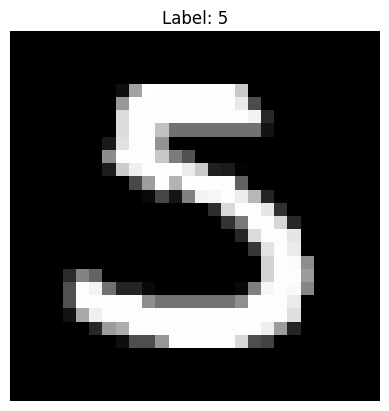

In [47]:
idx = np.random.randint(0, len(X_train))
image = X_train[idx].reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.title(f"Label: {Y_train[idx]}")
plt.axis('off')
plt.show()

# Building an MLP (Multilayer Perceptron) Model (NO CNN)



This is an MLP (Multilayer Perceptron) model, which is a simple neural network where every neuron is fully connected to all neurons in the next layer. It does not use any image-specific layers like CNN

In [48]:
model = keras.Sequential([

    # Input layer (784 pixels)
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),

    # Hidden layer
    keras.layers.Dense(64, activation='relu'),

    # Output layer (10 classes)
    keras.layers.Dense(10, activation='softmax')
])

print("\nModel Summary:")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling the MLP Model

In [52]:
model.compile(
    optimizer  ='adam',
    # Optimizer = learning method
    # Adam: an optimizer that automatically adjusts learning to train the model efficiently.
    loss='sparse_categorical_crossentropy',
    # Loss: a value that shows how wrong the model’s predictions are compared to the actual answers; lower loss means better performance.
    # Sparse categorical crossentropy: a loss function used to measure error when labels are single integers (0–9 classes)
    metrics=['accuracy']
    # Metrics = how we measure performance
    # Accuracy: a metric that shows how many predictions the model got correct out of total predictions.
)

# Train Model

In [53]:
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9189 - loss: 0.2778
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9648 - loss: 0.1163
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9747 - loss: 0.0804
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0597
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9857 - loss: 0.0454
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9880 - loss: 0.0372
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9901 - loss: 0.0294
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9913 - loss: 0.0255
Epoch 9/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9927 - loss: 0.0214
Epoch 10/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9938 - loss: 0.0178


# Prediction on Test Data

In [54]:
predictions = model.predict(X_test)

# Convert probabilities → final labels
pred_labels = np.argmax(predictions, axis=1)

print("\nFirst 10 Predictions:")
print(pred_labels[:10])

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

First 10 Predictions:
[2 0 9 9 3 7 0 3 0 3]


# Visualize Test Predictions

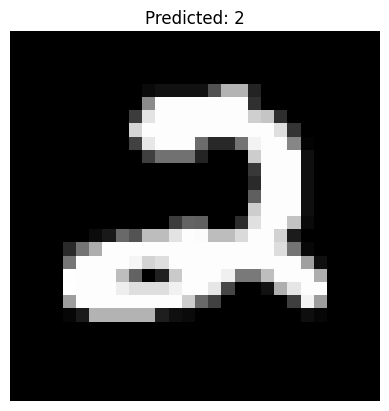

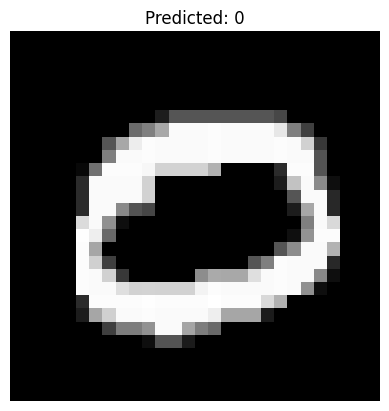

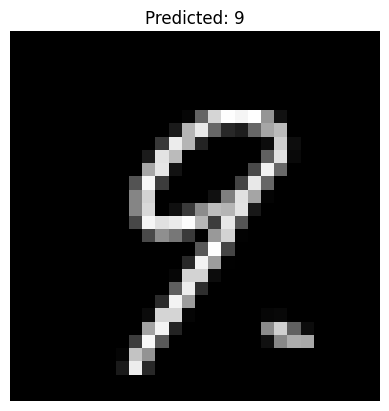

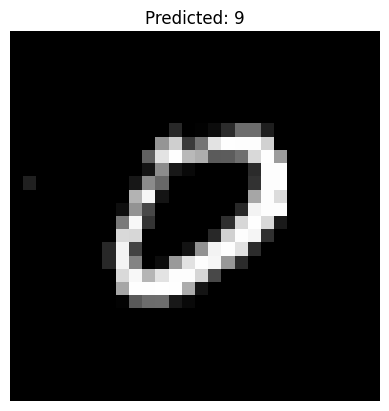

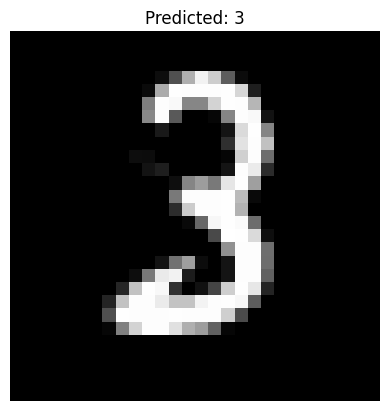

In [55]:
for i in range(5):
    image = X_test[i].reshape(28, 28)

    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]}")
    plt.axis('off')
    plt.show()

# Final Training Accuracy

In [56]:
final_acc = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]

print("\nFinal Training Accuracy:", final_acc)
print("Final Training Loss:", final_loss)


Final Training Accuracy: 0.9938333630561829
Final Training Loss: 0.017777008935809135


# Plot Training Accuracy and Loss

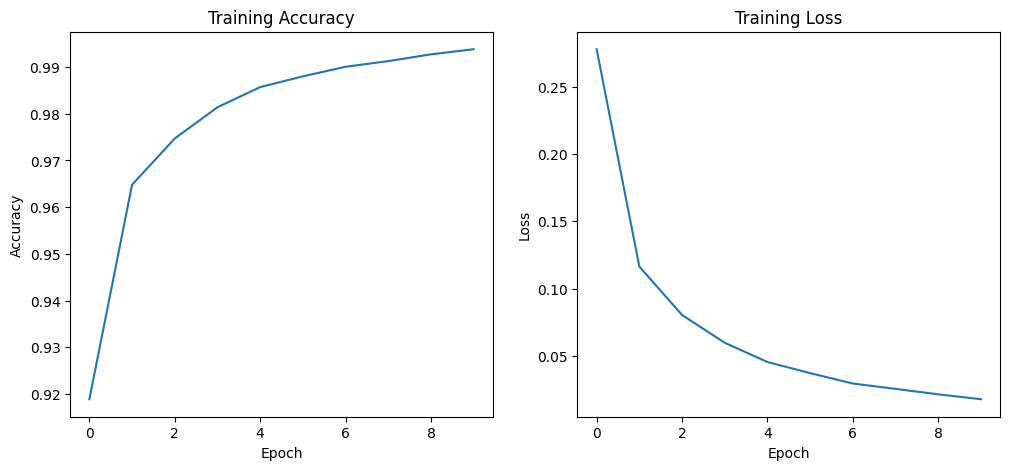

In [57]:
plt.figure(figsize=(12, 5))

# ---- Accuracy Plot ----
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# ---- Loss Plot ----
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

# Save Trained Model

In [58]:
model.save("mnist_mlp_model.h5")

print("Model saved successfully!")

Model saved successfully!


# Load Saved Model

In [59]:
from tensorflow import keras

loaded_model = keras.models.load_model("mnist_mlp_model.h5")

print("Model loaded successfully!")

Model loaded successfully!


# Making Predictions Using a Loaded Trained Model

ecause loading the model only brings it back, but it does NOT give results yet.
You still need to: give new data, ask the model to predict, convert output into final labels

In [60]:

predictions = loaded_model.predict(X_test)

# Convert probabilities → labels
pred_labels = np.argmax(predictions, axis=1)

print("First 10 Predictions:")
print(pred_labels[:10])

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
First 10 Predictions:
[2 0 9 9 3 7 0 3 0 3]


# Visualizing Model Predictions on Test Images

This code is used to check visually whether the model is predicting correctly or not by showing images with predicted labels.

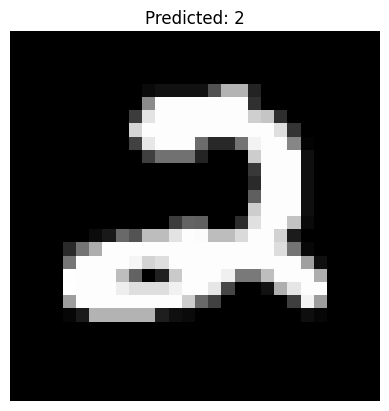

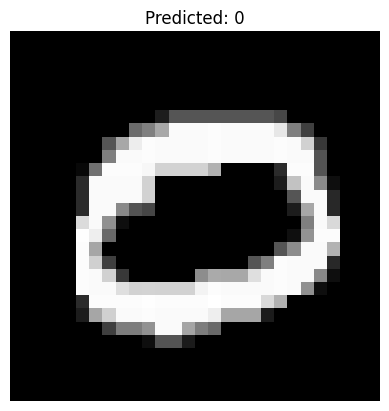

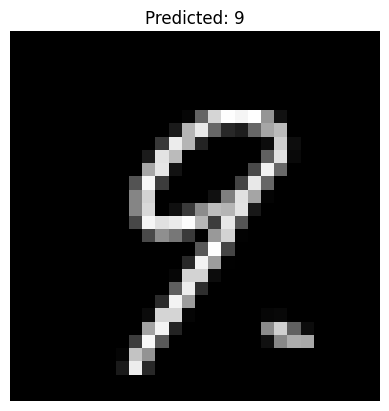

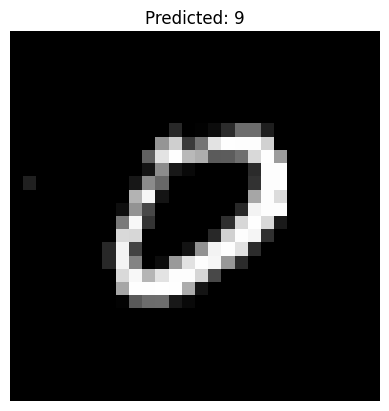

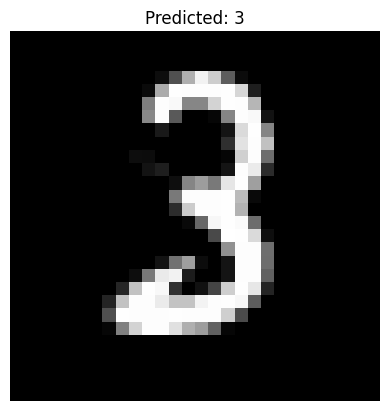

In [61]:
import matplotlib.pyplot as plt

for i in range(5):
    image = X_test[i].reshape(28, 28)

    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]}")
    plt.axis('off')
    plt.show()